**2. PREPARAÇÃO DOS DADOS**

Temos atualmente um dataset preparado para segmentação, com polígonos.
Para cumprir o trabalho, teremos dois experimentos:
1. Detecção de objetos → bounding boxes.
2. Segmentação de instâncias → utilização de polígonos existentes.

**Objetivo**

Nesta etapa serão preparados os dados para os experimentos
de detecção e segmentação de objetos.

O dataset original possui anotações no formato YOLO para
segmentação de instâncias, contendo polígonos que representam
os contornos dos objetos.

Para o experimento de detecção, esses polígonos serão
convertidos em bounding boxes no formato YOLO.

O dataset original será preservado para utilização no
experimento de segmentação.

**2.1 Upload e listagem do Dataset**

In [5]:
from google.colab import files

uploaded = files.upload()

Saving PPE.v6i.yolov8.zip to PPE.v6i.yolov8.zip


In [6]:
from pathlib import Path

zip_files = list(Path("/content").glob("*.zip"))

print("Arquivos ZIP encontrados:")

for file in zip_files:
    print(file)

Arquivos ZIP encontrados:
/content/PPE_dataset.zip
/content/PPE.v6i.yolov8.zip


In [8]:
from pathlib import Path

zip_files = list(Path("/content").glob("*.zip"))

for file in zip_files:
    print(file)

/content/PPE_dataset.zip
/content/PPE.v6i.yolov8.zip


In [9]:
import zipfile
from pathlib import Path

zip_path = Path("/content/PPE.v6i.yolov8.zip")
dataset_original = Path("/content/PPE_dataset")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(dataset_original)

print("Dataset descompactado em:")
print(dataset_original)

Dataset descompactado em:
/content/PPE_dataset


In [10]:
for split in ["train", "valid", "test"]:
    print(f"{split}:")
    print("  imagens:", len(list((dataset_original / split / "images").iterdir())))
    print("  labels: ", len(list((dataset_original / split / "labels").iterdir())))

train:
  imagens: 1617
  labels:  1617
valid:
  imagens: 75
  labels:  75
test:
  imagens: 44
  labels:  44


**2.2 Cópia limpa Dataset**

In [12]:
import shutil
from pathlib import Path

dataset_original = Path("/content/PPE_dataset")
dataset_clean = Path("/content/PPE_dataset_clean")

# Remove uma cópia limpa anterior, caso exista
if dataset_clean.exists():
    shutil.rmtree(dataset_clean)

# Copia todo o dataset
shutil.copytree(dataset_original, dataset_clean)

print("Cópia limpa criada em:")
print(dataset_clean)

Cópia limpa criada em:
/content/PPE_dataset_clean


In [13]:
arquivos_problematicos = {
    "train": [
        "frameHRGateDay-6-mp422000_jpg.rf.3d2f293e76e6684116e1f37927287c4f.txt",
        "frameHRGateDay-6-mp422000_jpg.rf.8b2b90e67dfdb25c41b31618b7f13a15.txt",
        "frameHRGateDay-6-mp422000_jpg.rf.8f6838da4874ddb2b77afe3157fd8f47.txt"
    ],
    "valid": [
        "frameHRGateDay-6-mp421000_jpg.rf.0a848b789a602dfcb85188607dc2d8ea.txt"
    ]
}

for split, arquivos in arquivos_problematicos.items():

    for nome_label in arquivos:

        label_path = dataset_clean / split / "labels" / nome_label

        # Nome da imagem correspondente
        imagem_nome = label_path.stem + ".jpg"
        imagem_path = dataset_clean / split / "images" / imagem_nome

        if label_path.exists():
            label_path.unlink()

        if imagem_path.exists():
            imagem_path.unlink()

print("Limpeza concluída.")

Limpeza concluída.


In [14]:
for split in ["train", "valid", "test"]:

    imagens = list((dataset_clean / split / "images").iterdir())
    labels = list((dataset_clean / split / "labels").iterdir())

    print(
        f"{split}: "
        f"{len(imagens)} imagens | "
        f"{len(labels)} labels"
    )

train: 1614 imagens | 1614 labels
valid: 74 imagens | 74 labels
test: 44 imagens | 44 labels


**2.3 Validação do data.yaml**

In [15]:
from pathlib import Path

yaml_path = dataset_clean / "data.yaml"

print(yaml_path.read_text())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 5
names: ['person', 'with-helmet', 'with-suit', 'without-helmet', 'without-suit']

roboflow:
  workspace: ppe-656ud
  project: ppe-fq2dk
  version: 6
  license: CC BY 4.0
  url: https://universe.roboflow.com/ppe-656ud/ppe-fq2dk/dataset/6


**2.4 Anotação**

In [16]:
from pathlib import Path

label_files = list(
    (dataset_clean / "train" / "labels").glob("*.txt")
)

arquivo_exemplo = label_files[0]

print("Arquivo:")
print(arquivo_exemplo.name)

print("\nConteúdo:")
print(arquivo_exemplo.read_text())

Arquivo:
frame6000_jpg.rf.5214c2cf151acdbf4076c2d097ccd30b.txt

Conteúdo:
0 0.9141139796875001 0.79954905 0.9170436671875001 0.7927131125 0.9248561671875001 0.7946662375 0.9395046046875001 0.78392405 0.9512233546875001 0.7253303 0.9453639796875001 0.688220925 0.9492702296875001 0.680408425 0.9492702296875001 0.656970925 0.9443874171875001 0.6501349875 0.9346217921875001 0.6501349875 0.9297389796875001 0.656970925 0.9316921046875001 0.6862678 0.9199733546875001 0.70579905 0.9141139796875001 0.739002175 0.9043483546875001 0.76048655 0.8945827296875001 0.8249396750000001 0.8848171046875001 0.8425178000000001 0.8936061671875001 0.8591193625000001 0.9082546046875001 0.8600959250000001 0.9141139796875001 0.8327521750000001 0.9141139796875001 0.79954905
2 0.939453125 0.7900390625 0.943359375 0.7587890625 0.9453125 0.7568359375 0.9453125 0.7431640625 0.94921875 0.7333984375 0.947265625 0.7294921875 0.947265625 0.7080078125 0.9453125 0.7021484375 0.9384765625 0.697265625 0.9306640625 0.69726562

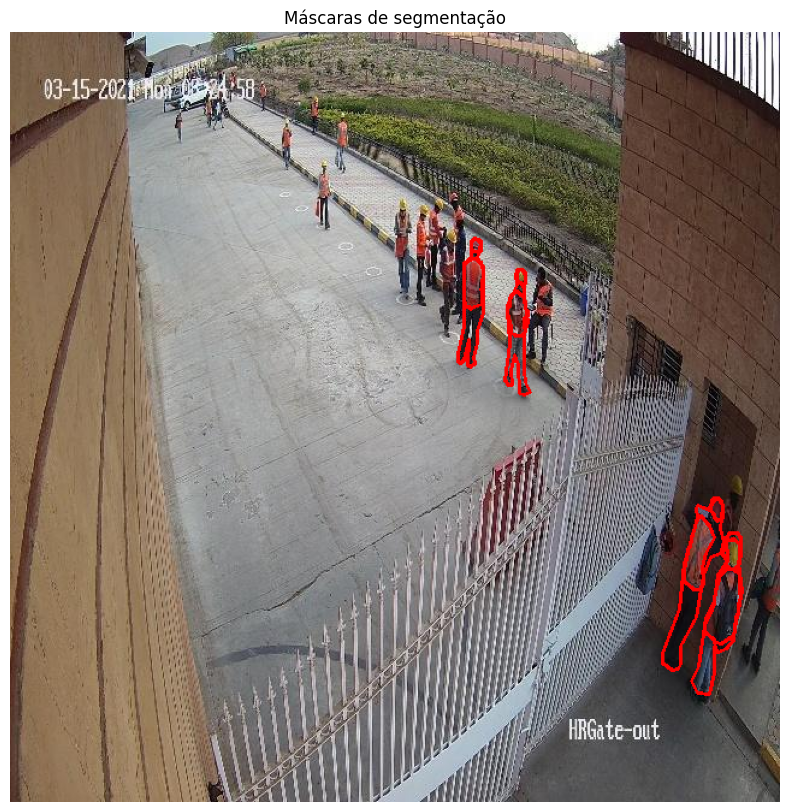

In [17]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Caminhos da imagem e da anotação
image_path = dataset_clean / "train" / "images" / (
    arquivo_exemplo.stem + ".jpg"
)

label_path = arquivo_exemplo

# Ler imagem
image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Copiar imagem para desenhar
visualizacao = image.copy()

# Ler as linhas da anotação
with open(label_path, "r") as f:
    linhas = f.readlines()

altura, largura = image.shape[:2]

for linha in linhas:

    valores = linha.strip().split()

    # Primeiro valor = classe
    classe = int(valores[0])

    # Demais valores = pontos x,y
    pontos = np.array(
        [
            [float(valores[i]) * largura,
             float(valores[i + 1]) * altura]
            for i in range(1, len(valores), 2)
        ],
        dtype=np.int32
    )

    # Desenhar contorno
    cv2.polylines(
        visualizacao,
        [pontos],
        isClosed=True,
        color=(255, 0, 0),
        thickness=2
    )

plt.figure(figsize=(10, 10))
plt.imshow(visualizacao)
plt.axis("off")
plt.title("Máscaras de segmentação")
plt.show()

**2.5 Teste de conversão de anotação**

In [18]:
def polygon_to_bbox(valores):
    """
    Converte uma anotação de segmentação YOLO
    para uma anotação de detecção YOLO.
    """

    # Primeiro valor = classe
    classe = int(valores[0])

    # Coordenadas do polígono
    coordenadas = list(map(float, valores[1:]))

    xs = coordenadas[0::2]
    ys = coordenadas[1::2]

    # Limites do polígono
    x_min = min(xs)
    x_max = max(xs)

    y_min = min(ys)
    y_max = max(ys)

    # Bounding box
    largura = x_max - x_min
    altura = y_max - y_min

    x_centro = (x_min + x_max) / 2
    y_centro = (y_min + y_max) / 2

    return [
        classe,
        x_centro,
        y_centro,
        largura,
        altura
    ]

In [19]:
with open(label_path, "r") as f:
    primeira_linha = f.readline().strip()

valores = primeira_linha.split()

bbox = polygon_to_bbox(valores)

print("Anotação original:")
print(primeira_linha)

print("\nBounding box calculada:")
print(bbox)

Anotação original:
0 0.9141139796875001 0.79954905 0.9170436671875001 0.7927131125 0.9248561671875001 0.7946662375 0.9395046046875001 0.78392405 0.9512233546875001 0.7253303 0.9453639796875001 0.688220925 0.9492702296875001 0.680408425 0.9492702296875001 0.656970925 0.9443874171875001 0.6501349875 0.9346217921875001 0.6501349875 0.9297389796875001 0.656970925 0.9316921046875001 0.6862678 0.9199733546875001 0.70579905 0.9141139796875001 0.739002175 0.9043483546875001 0.76048655 0.8945827296875001 0.8249396750000001 0.8848171046875001 0.8425178000000001 0.8936061671875001 0.8591193625000001 0.9082546046875001 0.8600959250000001 0.9141139796875001 0.8327521750000001 0.9141139796875001 0.79954905

Bounding box calculada:
[0, 0.9180202296875001, 0.75511545625, 0.06640625, 0.2099609375000001]


**2.6 Dataset de detecção**

In [20]:
from pathlib import Path
import shutil

dataset_det = Path("/content/PPE_dataset_detection")

# Apaga uma versão anterior, caso exista
if dataset_det.exists():
    shutil.rmtree(dataset_det)

# Cria a estrutura
for split in ["train", "valid", "test"]:
    (dataset_det / split / "images").mkdir(parents=True)
    (dataset_det / split / "labels").mkdir(parents=True)

print("Estrutura criada com sucesso.")

Estrutura criada com sucesso.


In [21]:
for split in ["train", "valid", "test"]:

    origem = dataset_clean / split / "images"
    destino = dataset_det / split / "images"

    for imagem in origem.iterdir():
        shutil.copy2(imagem, destino / imagem.name)

print("Imagens copiadas com sucesso.")

Imagens copiadas com sucesso.


In [22]:
for split in ["train", "valid", "test"]:

    origem = dataset_clean / split / "labels"
    destino = dataset_det / split / "labels"

    for label_file in origem.glob("*.txt"):

        novas_linhas = []

        with open(label_file, "r") as f:
            linhas = f.readlines()

        for linha in linhas:

            valores = linha.strip().split()

            # Ignora linhas vazias
            if not valores:
                continue

            bbox = polygon_to_bbox(valores)

            classe, x_centro, y_centro, largura, altura = bbox

            nova_linha = (
                f"{classe} "
                f"{x_centro:.6f} "
                f"{y_centro:.6f} "
                f"{largura:.6f} "
                f"{altura:.6f}\n"
            )

            novas_linhas.append(nova_linha)

        # Salvar nova anotação
        novo_label = destino / label_file.name

        with open(novo_label, "w") as f:
            f.writelines(novas_linhas)

print("Conversão concluída.")

Conversão concluída.


In [23]:
label_files_det = list(
    (dataset_det / "train" / "labels").glob("*.txt")
)

for arquivo in label_files_det[:3]:

    print("\nArquivo:", arquivo.name)

    with open(arquivo, "r") as f:
        linhas = f.readlines()

    for linha in linhas[:5]:
        print(linha.strip())


Arquivo: frame6000_jpg.rf.5214c2cf151acdbf4076c2d097ccd30b.txt
0 0.918020 0.755115 0.066406 0.209961
2 0.925781 0.750977 0.046875 0.107422
1 0.936523 0.677734 0.021484 0.039062
0 0.887695 0.717773 0.080078 0.220703
2 0.894531 0.676758 0.039062 0.095703

Arquivo: frame_HBHD2240_jpg.rf.3b59c270249a915a1d405e949794b94f.txt
0 0.661133 0.570312 0.236328 0.730469
2 0.680664 0.603516 0.197266 0.328125
1 0.691406 0.308105 0.097656 0.206055

Arquivo: bm_frame__m111_jpg.rf.32d2ad7a3cc13767856b5655714424f8.txt
0 0.546875 0.515137 0.117188 0.420898
2 0.553378 0.462165 0.101344 0.174594
1 0.555921 0.344676 0.052433 0.082599
0 0.449219 0.400391 0.093750 0.382812
2 0.441444 0.336831 0.073927 0.144280


**2.7 Visualização dos bounding boxes**

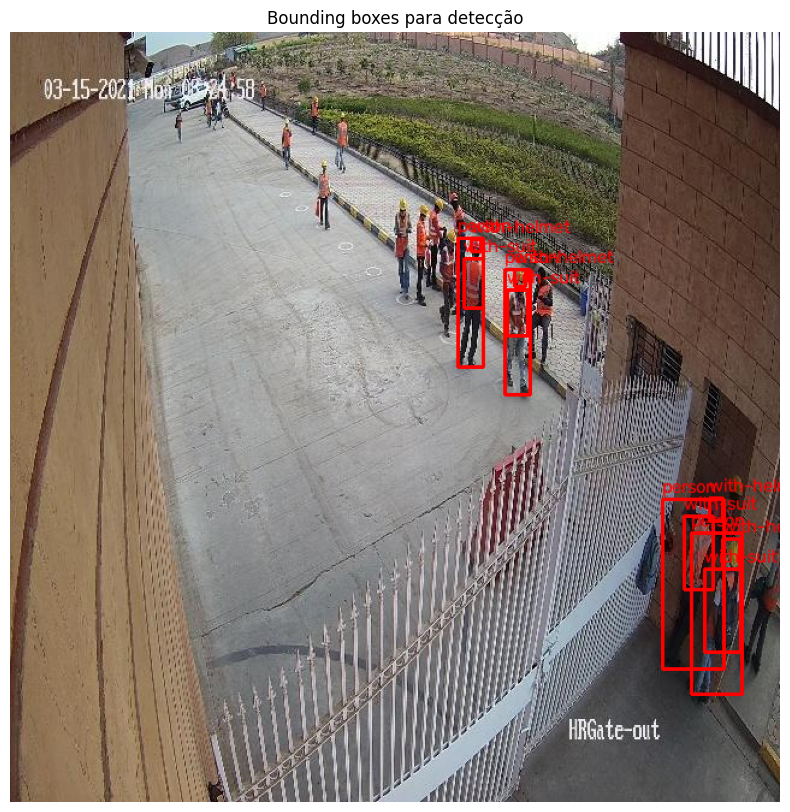

In [24]:
import cv2
import matplotlib.pyplot as plt

# Vamos usar o mesmo arquivo que analisamos anteriormente
image_path = dataset_det / "train" / "images" / (
    arquivo_exemplo.stem + ".jpg"
)

label_path_det = dataset_det / "train" / "labels" / (
    arquivo_exemplo.stem + ".txt"
)

# Ler imagem
image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

altura, largura = image.shape[:2]

# Ler anotações
with open(label_path_det, "r") as f:
    linhas = f.readlines()

visualizacao = image.copy()

# Nomes das classes
nomes_classes = [
    "person",
    "with-helmet",
    "with-suit",
    "without-helmet",
    "without-suit"
]

for linha in linhas:

    valores = linha.strip().split()

    classe = int(valores[0])

    x_centro = float(valores[1])
    y_centro = float(valores[2])
    box_largura = float(valores[3])
    box_altura = float(valores[4])

    # Converter de coordenadas normalizadas para pixels
    x_centro *= largura
    y_centro *= altura
    box_largura *= largura
    box_altura *= altura

    # Calcular cantos da bounding box
    x1 = int(x_centro - box_largura / 2)
    y1 = int(y_centro - box_altura / 2)

    x2 = int(x_centro + box_largura / 2)
    y2 = int(y_centro + box_altura / 2)

    # Desenhar retângulo
    cv2.rectangle(
        visualizacao,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    # Nome da classe
    texto = nomes_classes[classe]

    cv2.putText(
        visualizacao,
        texto,
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1
    )

plt.figure(figsize=(10, 10))
plt.imshow(visualizacao)
plt.axis("off")
plt.title("Bounding boxes para detecção")
plt.show()

**2.8 Criar o data.yaml da detecção**

In [25]:
data_yaml_detection = """
train: /content/PPE_dataset_detection/train/images
val: /content/PPE_dataset_detection/valid/images
test: /content/PPE_dataset_detection/test/images

nc: 5

names:
  0: person
  1: with-helmet
  2: with-suit
  3: without-helmet
  4: without-suit
"""

yaml_path_detection = dataset_det / "data.yaml"

with open(yaml_path_detection, "w") as f:
    f.write(data_yaml_detection)

print("data.yaml da detecção criado em:")
print(yaml_path_detection)

data.yaml da detecção criado em:
/content/PPE_dataset_detection/data.yaml


In [27]:
#conferir
print(yaml_path_detection.read_text())


train: /content/PPE_dataset_detection/train/images
val: /content/PPE_dataset_detection/valid/images
test: /content/PPE_dataset_detection/test/images

nc: 5

names:
  0: person
  1: with-helmet
  2: with-suit
  3: without-helmet
  4: without-suit



In [28]:
#verificar anotações
erros = []

for split in ["train", "valid", "test"]:

    images_path = dataset_det / split / "images"
    labels_path = dataset_det / split / "labels"

    imagens = list(images_path.iterdir())

    for imagem in imagens:

        label_path = labels_path / f"{imagem.stem}.txt"

        # Verificar se existe label
        if not label_path.exists():
            erros.append(
                f"{split}: imagem sem label -> {imagem.name}"
            )
            continue

        # Ler label
        with open(label_path, "r") as f:
            linhas = [linha.strip() for linha in f if linha.strip()]

        # Verificar label vazio
        if len(linhas) == 0:
            erros.append(
                f"{split}: label vazio -> {label_path.name}"
            )
            continue

        # Verificar cada anotação
        for numero_linha, linha in enumerate(linhas, start=1):

            valores = linha.split()

            # Deve ter 5 valores
            if len(valores) != 5:
                erros.append(
                    f"{split}: {label_path.name}, "
                    f"linha {numero_linha}: "
                    f"{len(valores)} valores"
                )
                continue

            classe = int(valores[0])
            coordenadas = list(map(float, valores[1:]))

            # Classe válida
            if classe < 0 or classe >= 5:
                erros.append(
                    f"{split}: {label_path.name}, "
                    f"classe inválida: {classe}"
                )

            # Coordenadas entre 0 e 1
            for valor in coordenadas:

                if valor < 0 or valor > 1:
                    erros.append(
                        f"{split}: {label_path.name}, "
                        f"coordenada inválida: {valor}"
                    )

print("Verificação concluída.")
print("Quantidade de erros:", len(erros))

if erros:
    print("\nPrimeiros erros encontrados:")
    for erro in erros[:20]:
        print(erro)
else:
    print("Nenhum erro encontrado!")

Verificação concluída.
Quantidade de erros: 0
Nenhum erro encontrado!


**2.9 Resumo de preparação dos dados**

In [29]:
print("======================================")
print(" RESUMO DA PREPARAÇÃO DOS DADOS")
print("======================================")

print("\nDataset de segmentação:")
print("  Train:", len(list((dataset_clean / "train" / "images").iterdir())))
print("  Valid:", len(list((dataset_clean / "valid" / "images").iterdir())))
print("  Test :", len(list((dataset_clean / "test" / "images").iterdir())))

print("\nDataset de detecção:")
print("  Train:", len(list((dataset_det / "train" / "images").iterdir())))
print("  Valid:", len(list((dataset_det / "valid" / "images").iterdir())))
print("  Test :", len(list((dataset_det / "test" / "images").iterdir())))

print("\nClasses:")
for i, nome in enumerate(nomes_classes):
    print(f"  {i}: {nome}")

print("\nControle de qualidade:")
print("  Erros encontrados:", len(erros))

 RESUMO DA PREPARAÇÃO DOS DADOS

Dataset de segmentação:
  Train: 1614
  Valid: 74
  Test : 44

Dataset de detecção:
  Train: 1614
  Valid: 74
  Test : 44

Classes:
  0: person
  1: with-helmet
  2: with-suit
  3: without-helmet
  4: without-suit

Controle de qualidade:
  Erros encontrados: 0
